# Google Trends preprocessing pipeline


| Module | What it does |
|---|---|
| `gtrends_download.py` | Pull raw Google Health Trends series per topic/location |
| `gtrends_cluster.py` | Flag sparse/duplicate keyword columns, cluster them together |
| `gtrends_denoise.py` | Rolling smoothing-spline denoise |
| `gtrends_detrend.py` | ADF-based detrending |
| `plotting.py` | Visualize clustering + denoise/detrend stages |


In [39]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

%matplotlib inline
import os
import pandas as pd

from lgbm_forecast import gtrends_download, io, gtrends_cluster, gtrends_denoise, gtrends_detrend, plotting

## Config

The list of countries comes from the latest Respicast files

In [2]:
LOCATIONS = gtrends_download.load_hub_locations()
print(len(LOCATIONS), "locations")
LOCATIONS

32 locations


['AT',
 'BE',
 'BG',
 'CH',
 'CY',
 'CZ',
 'DE',
 'DK',
 'EE',
 'ES',
 'FI',
 'FR',
 'GB-ENG',
 'GB-NIR',
 'GB-SCT',
 'GB-WLS',
 'GR',
 'HR',
 'HU',
 'IE',
 'IS',
 'IT',
 'LT',
 'LU',
 'LV',
 'MT',
 'NL',
 'NO',
 'PL',
 'RO',
 'SI',
 'SK']

## Step 1 — Download raw Google Trends series (optional)


In [46]:
key = ''

In [5]:
RUN_DOWNLOAD = False

# Testing against a single location for now to avoid burning API quota.
# Switch to DOWNLOAD_LOCATIONS = LOCATIONS for the full download.
DOWNLOAD_LOCATIONS = LOCATIONS

if RUN_DOWNLOAD:
    api_key = key

    # cluster_id=0 rows are single, unclustered topics — one per row, one term each.
    initial_topics = pd.DataFrame([
        {"location": loc, "cluster_id": 0, "terms": label}
        for loc in DOWNLOAD_LOCATIONS
        for label in gtrends_download.ALL_TOPICS
    ])

    gtrends_download.download_all(
        cluster_df=initial_topics,
        save_dir=str(RAW_DIR),
        api_key=api_key,
        start_date="2014-01-01",
        end_date=pd.Timestamp.today().strftime("%Y-%m-%d"),
    )

## Step 2 — Load raw series

In [6]:
google_df = io.load_timeseries_wide(str(RAW_DIR), LOCATIONS)
# google_df = google_df[google_df["date"] >= "2014-10-01"]

# one-off cleanup carried over from the original notebook
google_df = google_df.drop(columns=["cough cold & flu"], errors="ignore")

print(google_df.shape)
google_df.head()

(21088, 23)


,date,influenza,influenza B virus,sore throat,influenza A virus,nausea,influenza vaccine,fever,paracetamol,flu season,...,runny nose,common cold,cold medicine,throat lozenge,dyspnea,avian influenza,nasal congestion,headache,rapid influenza test,location
0,2013-12-29,896.557787,0.0,974.384668,0.0,1452.038445,0.000000,1846.917525,651.442969,0.0,...,0.0,1549.316837,254.111014,0.0,341.254445,0.0,149.650606,1502.419758,0.0,AT
1,2014-01-05,711.101511,0.0,780.452591,0.0,1255.454165,104.376578,1805.818686,736.703836,0.0,...,0.0,1523.031848,188.893302,0.0,331.665992,0.0,141.409396,1467.691455,0.0,AT
2,2014-01-12,755.039537,0.0,796.424444,0.0,1070.753240,0.000000,1830.695243,612.890298,0.0,...,0.0,1119.219410,212.712864,0.0,397.835107,0.0,168.343011,1494.499337,0.0,AT
3,2014-01-19,923.937653,0.0,748.003632,0.0,1176.098678,96.263664,2121.151427,662.304248,0.0,...,0.0,1209.381356,291.110805,0.0,406.757483,0.0,108.331452,1431.918957,0.0,AT
4,2014-01-26,950.644984,0.0,1052.839764,0.0,1133.828578,77.116079,2291.535758,658.263605,0.0,...,0.0,1343.427815,303.850721,0.0,298.346331,0.0,161.235452,1588.636541,0.0,AT


## Step 3 — Flag sparse / duplicate keyword columns

Columns with too many zero-weeks are unreliable alone; `make_zero_df` flags
them `CLUSTER` instead of dropping them outright.

In [7]:
zero_df = gtrends_cluster.make_zero_df(google_df)
ok_all = gtrends_cluster.make_ok_dict(zero_df)
zero_df[zero_df["action"] == "CLUSTER"].head()

action
OK         361
CLUSTER    200
Name: count, dtype: int64


,location,column,zero_pct,action
0,AT,rapid influenza test,91.805766,CLUSTER
1,AT,influenza B virus,89.226100,CLUSTER
2,AT,influenza A virus,86.798179,CLUSTER
3,AT,avian influenza,77.845220,CLUSTER
4,AT,runny nose,57.207891,CLUSTER


## Step 4 — Combine sparse keywords into one cluster per location

No correlation-based sub-clustering: every `CLUSTER`-flagged keyword for a
location is joined into a single `'+'`-joined query, so each location gets
exactly one cluster (`cluster_id=1`). Produces `cluster_all.csv`, ready to
feed back into `gtrends_download.download_all` as a combined query.

In [8]:
cluster_all = (
    zero_df[zero_df["action"] == "CLUSTER"]
    .groupby("location")["column"]
    .apply(lambda cols: " + ".join(sorted(cols)))
    .reset_index(name="terms")
)
cluster_all["cluster_id"] = 1
cluster_all = cluster_all[["location", "cluster_id", "terms"]]

cluster_all.to_csv(PROCESSED_DIR / "cluster_all.csv", index=False)
cluster_all

,location,cluster_id,terms
0,AT,1,avian influenza + influenza A virus + influenz...
1,BE,1,avian influenza + flu season + influenza A vir...
2,BG,1,avian influenza + cold medicine + influenza va...
3,CH,1,avian influenza + flu season + influenza A vir...
4,CY,1,cold medicine + dyspnea + influenza A virus + ...
5,CZ,1,avian influenza + cold medicine + influenza A ...
6,DE,1,flu season + influenza A virus + influenza B v...
7,DK,1,avian influenza + influenza A virus + influenz...
8,EE,1,avian influenza + cold medicine + dyspnea + na...
9,ES,1,flu season + influenza A virus + influenza B v...


## Step 5 — Download the clustered queries

Same as Step 1, but for the combined cluster queries. Re-run
`io.load_timeseries_wide(..., only_clusters=True)` afterwards to load them.

In [9]:
RUN_CLUSTER_DOWNLOAD = False

if RUN_CLUSTER_DOWNLOAD:
    api_key = key
    gtrends_download.download_all(
        cluster_df=cluster_all,
        save_dir=str(RAW_DIR),
        api_key=api_key,
        start_date="2014-01-01",
        end_date=pd.Timestamp.today().strftime("%Y-%m-%d"),
    )

google_cluster = io.load_timeseries_wide(str(RAW_DIR), LOCATIONS, only_clusters=True)
google_cluster.shape

+++ DOWNLOADING +++
  saved: time_series_AT_cluster_all.csv (7 term(s))
  saved: time_series_BE_cluster_all.csv (5 term(s))
  saved: time_series_BG_cluster_all.csv (5 term(s))
  saved: time_series_CH_cluster_all.csv (7 term(s))
  saved: time_series_CY_cluster_all.csv (7 term(s))
  saved: time_series_CZ_cluster_all.csv (6 term(s))
  saved: time_series_DE_cluster_all.csv (4 term(s))
  saved: time_series_DK_cluster_all.csv (6 term(s))
  saved: time_series_EE_cluster_all.csv (6 term(s))
  saved: time_series_ES_cluster_all.csv (4 term(s))
  saved: time_series_FI_cluster_all.csv (7 term(s))
  saved: time_series_FR_cluster_all.csv (3 term(s))
  saved: time_series_GB-ENG_cluster_all.csv (5 term(s))
  saved: time_series_GB-NIR_cluster_all.csv (7 term(s))
  saved: time_series_GB-SCT_cluster_all.csv (6 term(s))
  saved: time_series_GB-WLS_cluster_all.csv (7 term(s))
  saved: time_series_GR_cluster_all.csv (7 term(s))
  saved: time_series_HR_cluster_all.csv (7 term(s))
  saved: time_series_HU_clus

(21088, 3)

### Recheck — did clustering actually get under the 30% zero-weeks threshold?

In [14]:
cluster_zero_check = (
    google_cluster.groupby("location")["cluster_all"]
    .apply(lambda s: (s == 0).mean() * 100)
    .reset_index(name="zero_pct")
)
cluster_zero_check["under_30pct"] = cluster_zero_check["zero_pct"] < 30

# print(cluster_zero_check["under_30pct"].value_counts())
cluster_zero_check.sort_values("zero_pct", ascending=False)

cluster_zero_check[cluster_zero_check['under_30pct']==False]
location_no_cluster = cluster_zero_check[cluster_zero_check['under_30pct']==False]['location'].tolist()

## Step 6 — Reshape to long format

`make_selected_long` keeps only the OK (non-clustered) columns per location;
the cluster series (already one combined column per location) are added
the same way via a `{location: ["cluster_all"]}` mapping.

In [20]:
long_ok = gtrends_denoise.make_selected_long(google_df, ok_all)
cluster_dict = {loc: ["cluster_all"] for loc in google_cluster["location"].unique()}
for loc in location_no_cluster:
    cluster_dict.pop(loc, None)
long_cluster = gtrends_denoise.make_selected_long(google_cluster, cluster_dict)

long_all = pd.concat([long_ok, long_cluster], ignore_index=True)
long_all.head(5)

,date,location,variable,value
0,2013-12-29,AT,cold medicine,254.111014
1,2014-01-05,AT,cold medicine,188.893302
2,2014-01-12,AT,cold medicine,212.712864
3,2014-01-19,AT,cold medicine,291.110805
4,2014-01-26,AT,cold medicine,303.850721


## Step 7 — Denoise

In [22]:
denoised_all, denoise_summary = gtrends_denoise.do_denoise(long_all)

print(denoise_summary["denoised"].value_counts())
denoised_all.head(5)

denoised
True     322
False     69
Name: count, dtype: int64


,date,location,variable,value,denoised_value
0,2013-12-29,AT,cold medicine,254.111014,254.111014
1,2014-01-05,AT,cold medicine,188.893302,188.893302
2,2014-01-12,AT,cold medicine,212.712864,212.712864
3,2014-01-19,AT,cold medicine,291.110805,291.110805
4,2014-01-26,AT,cold medicine,303.850721,303.850721


In [23]:
denoised_all.isna().sum()

date              0
location          0
variable          0
value             0
denoised_value    0
dtype: int64

## Step 8 — Detrend + stationarity recheck

In [24]:
detrended_all, detrend_summary = gtrends_detrend.do_detrend(denoised_all)

recheck = gtrends_detrend.recheck_stationarity_adf(detrended_all, column="detrended_value")
recheck["stationarity_status"].value_counts()

stationarity_status
stationary around constant     388
trend-stationary: linear         2
trend-stationary: quadratic      1
Name: count, dtype: int64

In [ ]:
detrended_all.isna().sum()

date                0
location            0
variable            0
value               0
denoised_value      0
detrended_value    10
dtype: int64

In [35]:
detrended_all[detrended_all.isna().any(axis=1)]

,date,location,variable,value,denoised_value,detrended_value
19111,2013-12-29,BG,fever,783.315972,783.315972,NaN
33609,2013-12-29,CY,nausea,0.000000,0.000000,NaN
65241,2013-12-29,EE,nausea,1017.564737,1017.564737,NaN
81057,2013-12-29,FI,sore throat,832.753437,832.753437,NaN
99509,2013-12-29,GB-ENG,nausea,793.947320,793.947320,NaN
111371,2013-12-29,GB-NIR,nausea,1296.740648,1296.740648,NaN
156842,2013-12-29,IE,nausea,962.098502,962.098502,NaN
166068,2013-12-29,IT,sore throat,43.311815,43.311815,NaN
182543,2013-12-29,LV,fever,568.033040,568.033040,NaN
192428,2013-12-29,NL,runny nose,62.720062,62.720062,NaN


## Step 9 — Spot-check a series

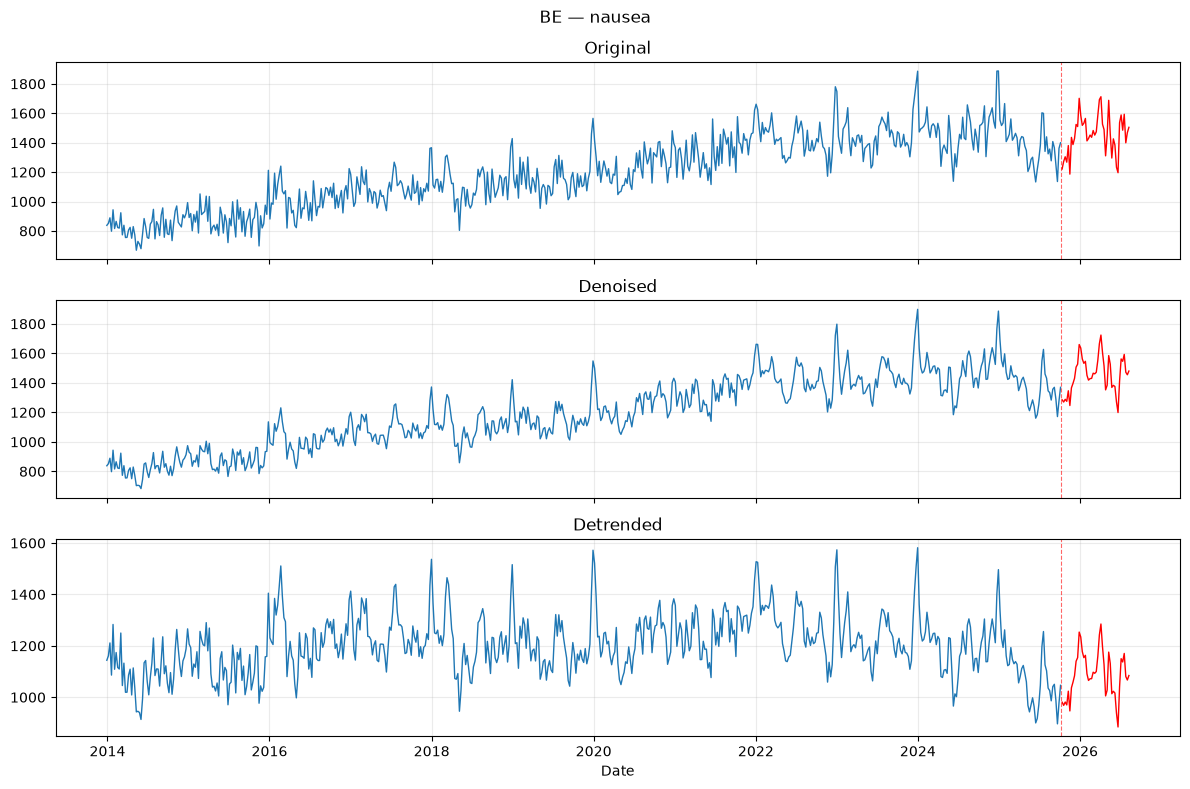

In [40]:
sample_loc = detrended_all["location"].iloc[0]
sample_var = detrended_all["variable"].iloc[0]
plotting.plot_preprocessing_single(detrended_all, location='BE', variable='nausea')

## Step 10 — Pivot to wide and save the feature table

This is the file the LightGBM training step (next notebook / module) reads.

In [41]:
gt_wide = detrended_all.pivot_table(
    index=["date", "location"], columns="variable", values="detrended_value", aggfunc="first"
).reset_index()
gt_wide.columns.name = None

gt_wide = gt_wide[gt_wide["date"] >= "2014-10-01"].reset_index(drop=True)

out_path = PROCESSED_DIR / "google_trends_preprocessed.csv"
gt_wide.to_csv(out_path, index=False)
print("Saved:", out_path, gt_wide.shape)
gt_wide.head()

Saved: /home/nadillia/Documents/LightGBM_Forecast/data/processed/google_trends_preprocessed.csv (19808, 19)


,date,location,avian influenza,cluster_all,cold medicine,common cold,cough,dyspnea,fever,headache,influenza,influenza vaccine,nasal congestion,nausea,paracetamol,runny nose,sore throat,throat lozenge,virus
0,2014-10-05,AT,NaN,445.419438,248.436733,1626.899178,1696.527019,342.331856,1991.322474,1668.656612,974.777554,NaN,154.860005,1279.498224,764.519645,NaN,938.151376,NaN,3742.921606
1,2014-10-05,BE,NaN,362.418823,53.655578,931.805711,947.011458,134.558634,1329.458519,1346.065252,943.477369,NaN,163.219555,1017.706597,834.124499,118.205144,546.127906,0.0,3429.966731
2,2014-10-05,BG,NaN,193.344418,NaN,1220.839772,2783.503876,146.230158,137.691998,963.394221,1187.117586,NaN,NaN,587.360544,750.360292,1672.560047,326.990331,NaN,3082.101354
3,2014-10-05,CH,NaN,362.401093,104.005643,1252.054687,1268.146399,251.733998,1643.081738,1831.417923,1200.108293,NaN,176.455647,1299.919548,972.907479,3.055955,591.450086,NaN,3578.876017
4,2014-10-05,CY,NaN,816.371685,NaN,1175.150688,1371.439807,NaN,1430.357086,2224.456609,0.000000,NaN,NaN,0.000000,972.591530,NaN,0.000000,NaN,4904.170288


In [44]:
gt_wide.tail(5)

,date,location,avian influenza,cluster_all,cold medicine,common cold,cough,dyspnea,fever,headache,influenza,influenza vaccine,nasal congestion,nausea,paracetamol,runny nose,sore throat,throat lozenge,virus
19803,2026-08-09,NO,NaN,379.430798,209.207521,1313.770397,2332.030274,211.454365,2013.926030,1725.061176,598.510923,NaN,221.756204,2164.815606,2765.487128,NaN,417.570779,NaN,1471.864887
19804,2026-08-09,PL,22.827998,44.752852,25.591532,558.266371,1602.191048,255.276612,1505.177048,1499.890461,510.344805,20.274759,136.105161,822.752931,1440.569277,NaN,625.010693,NaN,1892.599331
19805,2026-08-09,RO,NaN,195.938661,NaN,1136.725714,1388.947149,79.409394,1525.469581,1316.350235,574.869987,NaN,236.310905,1045.949694,1410.141748,102.53978,263.599372,NaN,1553.820270
19806,2026-08-09,SI,NaN,191.339162,NaN,480.071210,645.344184,NaN,4712.671722,648.889282,320.087076,NaN,NaN,1054.024537,832.118138,NaN,277.107322,NaN,1722.654970
19807,2026-08-09,SK,NaN,230.778532,NaN,621.650269,1544.306913,NaN,732.419360,1117.315439,534.738422,NaN,NaN,805.522102,1381.536774,NaN,433.099536,NaN,1029.842919


## Next: LightGBM training

Once the feature table above looks right, add a `model.py` (and `features.py`
for lag/calendar features on top of `google_trends_wide.csv`) to
`src/lgbm_forecast/`, import them the same way, and call them from a new
section here — same pattern, one function per step.